<a href="https://colab.research.google.com/github/Karthikreddy1010/MicroscopicPlastic-Semantic-segmentation/blob/main/ablation_3_efficientnetv2b3_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ABLATION EXPERIMENT 3: EfficientNetV2-B3 + Stage-Adaptive Attention (NO MRFM)

**Purpose:** Independently measure the contribution of Stage-Adaptive Attention (Edge Attention / Coordinate Attention / Channel-Spatial Attention), isolated from MRFM.

**Model:** EfficientNetV2-B3 encoder + Stage-Adaptive Attention at every encoder/decoder stage, simple decoder (no MRFM).

**Configuration:** Identical dataset, preprocessing, augmentation, losses, training strategy, and evaluation protocol as Ablation 1 and Ablation 2. The ONLY architectural difference from Ablation 1 is the addition of Stage-Adaptive Attention. MRFM is completely absent.

In [ ]:
!unzip /content/archive.zip

In [ ]:
!pip install tensorflow

In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras import mixed_precision
from tensorflow.keras.applications import EfficientNetV2B3
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from sklearn.metrics import precision_score, recall_score, f1_score
import seaborn as sns
from scipy import stats
import pandas as pd
from skimage.transform import rotate, resize
import warnings
warnings.filterwarnings('ignore')


# Confirm GPU
gpus = tf.config.list_physical_devices('GPU')
if len(gpus) > 0:
    print(" GPU detected:", gpus)
    # Enable memory growth
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

    # Enable mixed precision
    mixed_precision.set_global_policy('mixed_float16')
    print(" Mixed precision enabled")
else:
    print(" No GPU detected - running on CPU")

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Configuration - MUST MATCH ORIGINAL NOTEBOOK
IMG_HEIGHT = 512
IMG_WIDTH = 512
BATCH_SIZE = 4
EPOCHS = 100
PATIENCE = 15

# Paths to your data
TRAIN_IMAGE_DIR = '/content/training/training/Training_original'
TRAIN_MASK_DIR = '/content/training/training/Finalmasks'
VAL_IMAGE_DIR = '/content/val/val/Original'
VAL_MASK_DIR = '/content/val/val/val_100masks'
TEST_IMAGE_DIR = '/content/Testing/Testing/Original'
TEST_MASK_DIR = '/content/Testing/Testing/testing_100masks'

print(f"Configuration:")
print(f"  Image size: {IMG_HEIGHT} × {IMG_WIDTH}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max epochs: {EPOCHS}")
print(f"  Patience: {PATIENCE}")

 GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
 Mixed precision enabled
Configuration:
  Image size: 512 × 512
  Batch size: 4
  Max epochs: 100
  Patience: 15


In [4]:
# ============================================================================
# DATA LOADING & PREPROCESSING (IDENTICAL TO ORIGINAL)
# ============================================================================

def normalize_name(name):
    """Normalize filename for matching."""
    name = os.path.basename(name)
    name = os.path.splitext(name)[0]
    name = name.replace('_mask', '')
    return name


def preprocess_mask(mask):
    """Proper mask binarization."""
    mask_binary = (mask > 127).astype(np.float32)
    return mask_binary


def calculate_iou(y_true, y_pred):
    """Calculate Intersection over Union for binary masks."""
    y_true = y_true.flatten().astype(np.uint8)
    y_pred = y_pred.flatten().astype(np.uint8)

    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection

    if union == 0:
        return 0.0

    return intersection / union


def calculate_miou(y_true, y_pred):
    """Calculate mean Intersection over Union for both classes."""
    y_true = y_true.flatten().astype(np.uint8)
    y_pred = y_pred.flatten().astype(np.uint8)

    iou_class_0 = calculate_iou(1 - y_true, 1 - y_pred)  # Background
    iou_class_1 = calculate_iou(y_true, y_pred)           # Foreground

    miou = (iou_class_0 + iou_class_1) / 2.0

    return {
        'iou_background': iou_class_0,
        'iou_foreground': iou_class_1,
        'miou': miou
    }


def calculate_iou_metric(y_true, y_pred):
    """
    Calculate standard IoU (Intersection over Union) metric.
    """
    y_true_flat = y_true.flatten().astype(np.uint8)
    y_pred_flat = y_pred.flatten().astype(np.uint8)

    intersection = np.sum(y_true_flat * y_pred_flat)
    union = np.sum(y_true_flat) + np.sum(y_pred_flat) - intersection

    if union == 0:
        return 1.0 if intersection == 0 else 0.0

    iou = intersection / union
    return iou


def calculate_iou_per_image(y_true, y_pred):
    """Calculate IoU for each image individually."""
    ious = []
    for i in range(len(y_true)):
        gt = y_true[i].flatten().astype(np.uint8)
        pred = y_pred[i].flatten().astype(np.uint8)

        intersection = np.sum(gt * pred)
        union = np.sum(gt) + np.sum(pred) - intersection

        if union == 0:
            iou = 1.0 if intersection == 0 else 0.0
        else:
            iou = intersection / union
        ious.append(iou)

    return np.array(ious)


def calculate_comprehensive_iou_metrics(y_true, y_pred):
    """Calculate comprehensive IoU metrics."""
    y_true_flat = y_true.flatten().astype(np.uint8)
    y_pred_flat = y_pred.flatten().astype(np.uint8)

    iou_bg = calculate_iou(1 - y_true_flat, 1 - y_pred_flat)
    iou_fg = calculate_iou(y_true_flat, y_pred_flat)
    miou = (iou_bg + iou_fg) / 2.0

    iou_standard = calculate_iou_metric(y_true, y_pred)
    per_image_ious = calculate_iou_per_image(y_true, y_pred)

    return {
        'iou': iou_standard,
        'iou_background': iou_bg,
        'iou_foreground': iou_fg,
        'miou': miou,
        'iou_mean': np.mean(per_image_ious),
        'iou_std': np.std(per_image_ious),
        'iou_median': np.median(per_image_ious),
        'iou_min': np.min(per_image_ious),
        'iou_max': np.max(per_image_ious),
        'per_image_ious': per_image_ious
    }


def calculate_segmentation_metrics(y_true, y_pred_binary):
    """Calculate pixel-wise segmentation metrics."""
    y_true_flat = y_true.flatten().astype(np.uint8)
    y_pred_flat = y_pred_binary.flatten().astype(np.uint8)

    precision = precision_score(y_true_flat, y_pred_flat, zero_division=0)
    recall = recall_score(y_true_flat, y_pred_flat, zero_division=0)
    f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)

    intersection = np.sum(y_true_flat * y_pred_flat)
    dice = (2. * intersection) / (np.sum(y_true_flat) + np.sum(y_pred_flat) + 1e-8)

    iou_metrics = calculate_comprehensive_iou_metrics(y_true, y_pred_binary)

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'dice': dice,
        'iou': iou_metrics['iou'],
        'iou_background': iou_metrics['iou_background'],
        'iou_foreground': iou_metrics['iou_foreground'],
        'miou': iou_metrics['miou'],
        'iou_mean': iou_metrics['iou_mean'],
        'iou_std': iou_metrics['iou_std'],
        'iou_median': iou_metrics['iou_median'],
        'iou_min': iou_metrics['iou_min'],
        'iou_max': iou_metrics['iou_max']
    }


print(" Utility functions defined")

 Utility functions defined


In [5]:
# ============================================================================
# AUGMENTATION PIPELINE (IDENTICAL TO ORIGINAL)
# ============================================================================

def augment_geometric_numpy(image, mask, seed=None):
    """Apply geometric augmentations (rotation, zoom, flip) with consistent randomness."""
    if hasattr(image, 'numpy'):
        image = image.numpy()
    if hasattr(mask, 'numpy'):
        mask = mask.numpy()

    image = np.asarray(image, dtype=np.float32)
    mask = np.asarray(mask, dtype=np.float32)

    if seed is not None:
        np.random.seed(seed)

    h, w = image.shape[:2]

    # Random rotation
    if np.random.rand() < 0.5:
        angle = np.random.uniform(-15, 15)
        image = rotate(image, angle, mode='reflect', preserve_range=True)
        mask = rotate(mask, angle, mode='reflect', preserve_range=True)

    # Random zoom
    if np.random.rand() < 0.5:
        zoom_factor = np.random.uniform(0.9, 1.1)
        new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)

        image_zoomed = resize(image, (new_h, new_w), preserve_range=True, anti_aliasing=True)
        mask_zoomed = resize(mask, (new_h, new_w), preserve_range=True, anti_aliasing=False, order=0)

        if zoom_factor > 1.0:
            start_h = (new_h - h) // 2
            start_w = (new_w - w) // 2
            image = image_zoomed[start_h:start_h+h, start_w:start_w+w]
            mask = mask_zoomed[start_h:start_h+h, start_w:start_w+w]
        else:
            pad_h = (h - new_h) // 2
            pad_w = (w - new_w) // 2

            if len(mask_zoomed.shape) == 3:
                image = np.pad(image_zoomed, ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w), (0, 0)),
                              mode='reflect')
                mask = np.pad(mask_zoomed, ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w), (0, 0)),
                             mode='constant', constant_values=0)
            else:
                image = np.pad(image_zoomed, ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w), (0, 0)),
                              mode='reflect')
                mask = np.pad(mask_zoomed, ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w)),
                             mode='constant', constant_values=0)

    # Random horizontal flip
    if np.random.rand() < 0.5:
        image = np.fliplr(image)
        mask = np.fliplr(mask)

    # Random vertical flip
    if np.random.rand() < 0.5:
        image = np.flipud(image)
        mask = np.flipud(mask)

    if len(mask.shape) == 2:
        mask = np.expand_dims(mask, axis=-1)

    return image.astype(np.float32), mask.astype(np.float32)


def augment_photometric_numpy(image, seed=None):
    """Apply photometric augmentations to image only."""
    if hasattr(image, 'numpy'):
        image = image.numpy()

    image = np.asarray(image, dtype=np.float32)

    if seed is not None:
        np.random.seed(seed)

    brightness = np.random.uniform(-0.05, 0.05)
    image = image + brightness

    contrast = np.random.uniform(0.95, 1.05)
    mean = image.mean()
    image = (image - mean) * contrast + mean

    gamma = np.random.uniform(0.95, 1.05)
    image = np.power(np.clip(image, 0, 1), gamma)

    noise = np.random.normal(0, 0.005, image.shape).astype(np.float32)
    image = image + noise

    image = np.clip(image, 0, 1)

    return image.astype(np.float32)


def augment_combined_numpy(image, mask):
    """Combined augmentation pipeline."""
    if hasattr(image, 'numpy'):
        image = image.numpy()
    if hasattr(mask, 'numpy'):
        mask = mask.numpy()

    image = np.asarray(image, dtype=np.float32)
    mask = np.asarray(mask, dtype=np.float32)

    seed = np.random.randint(0, 10000)

    image, mask = augment_geometric_numpy(image, mask, seed=seed)
    image = augment_photometric_numpy(image, seed=seed+100)

    return image, mask


print(" Augmentation functions defined")

 Augmentation functions defined


In [6]:
# ============================================================================
# DATA LOADING (IDENTICAL TO ORIGINAL)
# ============================================================================

def load_data_raw(image_dir, mask_dir):
    """Load RAW data without preprocessing - returns [0, 1] range."""
    print(f"Loading RAW data from: {image_dir}")

    if not os.path.exists(image_dir):
        raise ValueError(f"Image directory does not exist: {image_dir}")

    if not os.path.exists(mask_dir):
        raise ValueError(f"Mask directory does not exist: {mask_dir}")

    image_paths = sorted([
        os.path.join(image_dir, fname)
        for fname in os.listdir(image_dir)
        if fname.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

    print(f"Found {len(image_paths)} images")

    images = []
    masks = []

    for img_idx, img_path in enumerate(image_paths):
        fname = os.path.basename(img_path)
        fname_key = normalize_name(fname)

        mask_found = False
        mask_path = None

        mask_candidate = os.path.join(mask_dir, fname_key + '_mask.png')
        if os.path.exists(mask_candidate):
            mask_path = mask_candidate
            mask_found = True

        if not mask_found:
            for ext in ['.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG']:
                mask_candidate = os.path.join(mask_dir, fname_key + ext)
                if os.path.exists(mask_candidate):
                    mask_path = mask_candidate
                    mask_found = True
                    break

        if not mask_found:
            base_name = os.path.splitext(fname)[0]
            for ext in ['.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG']:
                mask_candidate = os.path.join(mask_dir, base_name + ext)
                if os.path.exists(mask_candidate):
                    mask_path = mask_candidate
                    mask_found = True
                    break

        if not mask_found or mask_path is None:
            if img_idx < 5:
                print(f"Warning: No mask found for {fname_key}")
            continue

        try:
            img = Image.open(img_path).convert('RGB')
            img = img.resize((IMG_WIDTH, IMG_HEIGHT), Image.BILINEAR)
            img_array = np.array(img, dtype=np.float32) / 255.0

            mask = Image.open(mask_path).convert('L')
            mask = mask.resize((IMG_WIDTH, IMG_HEIGHT), Image.NEAREST)
            mask_array = np.array(mask, dtype=np.float32)
            mask_array = preprocess_mask(mask_array)
            mask_array = np.expand_dims(mask_array, axis=-1)

            images.append(img_array)
            masks.append(mask_array)

            if img_idx < 3:
                print(f"  Loaded: {fname_key} -> shape: {img_array.shape}")

        except Exception as e:
            print(f"Error loading {fname}: {e}")
            continue

    if len(images) == 0:
        raise ValueError(f"No valid images loaded from {image_dir}")

    images = np.array(images, dtype=np.float32)
    masks = np.array(masks, dtype=np.float32)

    print(f"\nSuccessfully loaded {len(images)} images")
    print(f"Image shape: {images.shape}")
    print(f"Image range: [{images.min():.4f}, {images.max():.4f}]")
    print(f"Mask shape: {masks.shape}")

    return images, masks


def create_augmented_dataset_with_preprocessing(images, masks, batch_size, augment=True, shuffle=True):
    """Create tf.data.Dataset with augmentation THEN preprocessing."""

    def preprocess_for_efficientnet(img, mask):
        img = img * 255.0
        img = preprocess_input(img)
        return img, mask

    dataset = tf.data.Dataset.from_tensor_slices((images, masks))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(images), reshuffle_each_iteration=True)

    if augment:
        def augment_fn(img, mask):
            img, mask = tf.py_function(
                func=augment_combined_numpy,
                inp=[img, mask],
                Tout=[tf.float32, tf.float32]
            )
            img.set_shape([IMG_HEIGHT, IMG_WIDTH, 3])
            mask.set_shape([IMG_HEIGHT, IMG_WIDTH, 1])
            return img, mask

        dataset = dataset.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.map(preprocess_for_efficientnet, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


print("\n" + "="*80)
print("LOADING RAW DATA (NO PREPROCESSING YET)")
print("="*80)

X_train, y_train = load_data_raw(TRAIN_IMAGE_DIR, TRAIN_MASK_DIR)
X_val, y_val = load_data_raw(VAL_IMAGE_DIR, VAL_MASK_DIR)
X_test, y_test = load_data_raw(TEST_IMAGE_DIR, TEST_MASK_DIR)

print(f"\nData shapes:")
print(f"Training:   X={X_train.shape}, y={y_train.shape}")
print(f"Validation: X={X_val.shape}, y={y_val.shape}")
print(f"Test:       X={X_test.shape}, y={y_test.shape}")

print("\n" + "="*80)
print("CREATING DATASETS WITH PREPROCESSING PIPELINE")
print("="*80)

train_dataset = create_augmented_dataset_with_preprocessing(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    augment=True,
    shuffle=True
)

val_dataset = create_augmented_dataset_with_preprocessing(
    X_val, y_val,
    batch_size=BATCH_SIZE,
    augment=False,
    shuffle=False
)

test_dataset = create_augmented_dataset_with_preprocessing(
    X_test, y_test,
    batch_size=BATCH_SIZE,
    augment=False,
    shuffle=False
)

print(" Datasets created successfully:")
print(f"   Training:   {len(X_train)} samples (augment → preprocess)")
print(f"   Validation: {len(X_val)} samples (preprocess only)")
print(f"   Test:       {len(X_test)} samples (preprocess only)")

print("\n Verifying preprocessing pipeline:")
for img_batch, mask_batch in train_dataset.take(1):
    print(f"   Batch shape: {img_batch.shape}")
    print(f"   After preprocessing: range=[{img_batch.numpy().min():.4f}, {img_batch.numpy().max():.4f}]")
    print(f"   Mean: {img_batch.numpy().mean():.4f}")
    break

print("="*80)

# ============================================================================
# SANITY CHECK: DATASET COUNTS
# ============================================================================
print("\n" + "="*80)
print(" DATASET SANITY CHECKS")
print("="*80)
print(f"Training image count:   {len(X_train)}")
print(f"Training mask count:    {len(y_train)}")
print(f"Validation image count: {len(X_val)}")
print(f"Validation mask count:  {len(y_val)}")
print(f"Test image count:       {len(X_test)}")
print(f"Test mask count:        {len(y_test)}")

if len(X_train) != len(y_train):
    raise ValueError("Training image/mask count mismatch!")
if len(X_val) != len(y_val):
    raise ValueError("Validation image/mask count mismatch!")
if len(X_test) != len(y_test):
    raise ValueError("Test image/mask count mismatch!")
if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
    raise ValueError("One or more dataset splits is empty!")

print(" All image/mask counts verified and consistent")
print("="*80)


LOADING RAW DATA (NO PREPROCESSING YET)
Loading RAW data from: /content/training/training/Training_original
Found 556 images
  Loaded: 100_jpg.rf.f1b9d16649ab385e3691fa54301a3b61 -> shape: (512, 512, 3)
  Loaded: 106_jpg.rf.e8dc04354de3fadaea50922857adf45e -> shape: (512, 512, 3)
  Loaded: 10_jpg.rf.ecfa6fcdfec86c013936528ac959e40d -> shape: (512, 512, 3)

Successfully loaded 556 images
Image shape: (556, 512, 512, 3)
Image range: [0.0000, 1.0000]
Mask shape: (556, 512, 512, 1)
Loading RAW data from: /content/val/val/Original
Found 208 images
  Loaded: a--47-_jpg.rf.4b52f93a6fb94ded6e3a16355ccdf382 -> shape: (512, 512, 3)
  Loaded: a--54-_jpg.rf.0383febe7b193195524f26c0df25ea8c -> shape: (512, 512, 3)
  Loaded: a--56-_jpg.rf.b47891c3c1b3bdf692a27eed2ed119ab -> shape: (512, 512, 3)

Successfully loaded 100 images
Image shape: (100, 512, 512, 3)
Image range: [0.0000, 1.0000]
Mask shape: (100, 512, 512, 1)
Loading RAW data from: /content/Testing/Testing/Original
Found 200 images
  Loaded

In [7]:
# ============================================================================
# MODEL ARCHITECTURE: EfficientNetV2B3 + STAGE-ADAPTIVE ATTENTION (NO MRFM)
# ============================================================================
# Attention mechanisms reused verbatim from the project source
# (final_microplastic_segmentation.ipynb): EdgeAttention (early/high-res
# stages), CoordinateAttention (middle stages), ChannelSpatialAttention
# (deep/low-res stages), wrapped by MicroplasticAttention. Applied at the
# same stage locations as the full proposed model's enc1..enc5 / dec4..dec1
# attention placements. NO MRFM modules are used anywhere in this model.
# ============================================================================

# ----------------------------------------------------------------------
# EDGE ATTENTION (for early stages - high resolution)
# ----------------------------------------------------------------------
class EdgeAttention(layers.Layer):
    """
    Edge-aware attention for high-resolution early stages.
    Emphasizes boundaries and fine details.
    """
    def __init__(self, channels, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels

    def build(self, input_shape):
        self.edge_conv = layers.Conv2D(
            self.channels, 3, padding='same',
            activation='relu',
            kernel_initializer='he_normal',
            name=f'{self.name}_edge_detector'
        )
        self.attention_conv = layers.Conv2D(
            self.channels, 1, padding='same',
            activation='sigmoid',
            kernel_initializer='glorot_uniform',
            name=f'{self.name}_edge_attention'
        )
        super().build(input_shape)

    def call(self, x):
        edges = self.edge_conv(x)
        attention = self.attention_conv(edges)
        return x * attention

    def get_config(self):
        config = super().get_config()
        config.update({'channels': self.channels})
        return config


# ----------------------------------------------------------------------
# COORDINATE ATTENTION (for middle stages)
# ----------------------------------------------------------------------
class CoordinateAttention(layers.Layer):
    """
    Coordinate attention for middle stages.
    Captures spatial dependencies along horizontal and vertical axes.
    """
    def __init__(self, channels, reduction=8, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.reduction = reduction

    def build(self, input_shape):
        self.conv1 = layers.Conv2D(
            self.channels // self.reduction, 1,
            activation='relu',
            kernel_initializer='he_normal',
            name=f'{self.name}_coord_reduce'
        )
        self.conv_h = layers.Conv2D(
            self.channels, 1,
            activation='sigmoid',
            kernel_initializer='glorot_uniform',
            name=f'{self.name}_coord_h'
        )
        self.conv_w = layers.Conv2D(
            self.channels, 1,
            activation='sigmoid',
            kernel_initializer='glorot_uniform',
            name=f'{self.name}_coord_w'
        )
        super().build(input_shape)

    def call(self, x):
        shape = tf.shape(x)
        height = shape[1]
        width = shape[2]

        pool_h = tf.reduce_mean(x, axis=2, keepdims=True)  # [B, H, 1, C]
        pool_w = tf.reduce_mean(x, axis=1, keepdims=True)  # [B, 1, W, C]

        pool_w_t = tf.transpose(pool_w, [0, 2, 1, 3])  # [B, W, 1, C]
        concat = tf.concat([pool_h, pool_w_t], axis=1)  # [B, H+W, 1, C]

        concat = self.conv1(concat)

        split_h, split_w = tf.split(concat, [height, width], axis=1)
        split_w = tf.transpose(split_w, [0, 2, 1, 3])

        att_h = self.conv_h(split_h)
        att_w = self.conv_w(split_w)

        return x * att_h * att_w

    def get_config(self):
        config = super().get_config()
        config.update({
            'channels': self.channels,
            'reduction': self.reduction
        })
        return config


# ----------------------------------------------------------------------
# CHANNEL + SPATIAL ATTENTION (for deep stages)
# ----------------------------------------------------------------------
class ChannelSpatialAttention(layers.Layer):
    """
    Combined channel and spatial attention for deep stages.
    Emphasizes important features and regions.
    """
    def __init__(self, channels, reduction=8, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.reduction = reduction

    def build(self, input_shape):
        self.global_avg_pool = layers.GlobalAveragePooling2D(keepdims=False)
        self.global_max_pool = layers.GlobalMaxPooling2D(keepdims=False)

        self.fc1 = layers.Dense(
            self.channels // self.reduction,
            activation='relu',
            kernel_initializer='he_normal',
            name=f'{self.name}_channel_fc1'
        )
        self.fc2 = layers.Dense(
            self.channels,
            activation='sigmoid',
            kernel_initializer='glorot_uniform',
            name=f'{self.name}_channel_fc2'
        )

        self.spatial_conv = layers.Conv2D(
            1, 7, padding='same',
            activation='sigmoid',
            kernel_initializer='glorot_uniform',
            name=f'{self.name}_spatial_attention'
        )
        super().build(input_shape)

    def call(self, x):
        avg_pool = self.global_avg_pool(x)
        max_pool = self.global_max_pool(x)

        avg_out = self.fc2(self.fc1(avg_pool))
        max_out = self.fc2(self.fc1(max_pool))

        channel_att = avg_out + max_out
        channel_att = tf.reshape(channel_att, [-1, 1, 1, self.channels])
        x_channel = x * channel_att

        avg_spatial = tf.reduce_mean(x_channel, axis=-1, keepdims=True)
        max_spatial = tf.reduce_max(x_channel, axis=-1, keepdims=True)
        spatial_concat = tf.concat([avg_spatial, max_spatial], axis=-1)

        spatial_att = self.spatial_conv(spatial_concat)
        x_spatial = x_channel * spatial_att

        return x_spatial

    def get_config(self):
        config = super().get_config()
        config.update({
            'channels': self.channels,
            'reduction': self.reduction
        })
        return config


# ----------------------------------------------------------------------
# MICROPLASTIC ATTENTION BLOCK (Stage-Adaptive)
# ----------------------------------------------------------------------
class MicroplasticAttention(layers.Layer):
    """
    Stage-adaptive attention for microplastic segmentation:
    - Early stages (high resolution): Edge Attention
    - Middle stages: Coordinate Attention
    - Deep stages (low resolution): Channel + Spatial Attention
    """
    def __init__(self, channels, stage='early', **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.stage = stage

    def build(self, input_shape):
        if self.stage == 'early':
            self.attention = EdgeAttention(self.channels, name=f'{self.name}_edge')
        elif self.stage == 'middle':
            self.attention = CoordinateAttention(self.channels, name=f'{self.name}_coord')
        elif self.stage == 'deep':
            self.attention = ChannelSpatialAttention(self.channels, name=f'{self.name}_chan_spat')
        else:
            raise ValueError(f"Invalid stage: {self.stage}. Must be 'early', 'middle', or 'deep'")

        super().build(input_shape)

    def call(self, x):
        return self.attention(x)

    def get_config(self):
        config = super().get_config()
        config.update({
            'channels': self.channels,
            'stage': self.stage
        })
        return config


def build_efficientnetv2b3_attention_unet(input_shape=(512, 512, 3)):
    """
    Build EfficientNetV2B3-based U-Net WITH Stage-Adaptive Attention and
    WITHOUT MRFM. This isolates the contribution of Stage-Adaptive
    Attention for Ablation 3.
    Output shape: (batch_size, 512, 512, 1)
    """
    inputs = layers.Input(shape=input_shape, name='input_image')

    # Backbone encoder (trainable)
    backbone = EfficientNetV2B3(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs
    )
    backbone.trainable = True

    print(f" Backbone trainable: {backbone.trainable}")
    print(f" Total backbone layers: {len(backbone.layers)}")

    # Extract encoder features
    try:
        e1 = backbone.get_layer('block1b_add').output      # ~256x256
        e2 = backbone.get_layer('block2b_add').output      # ~128x128
        e3 = backbone.get_layer('block3b_add').output      # ~64x64
        e4 = backbone.get_layer('block5c_add').output      # ~32x32
        e5 = backbone.get_layer('top_activation').output   # ~16x16
        print(" Successfully extracted all encoder features")
    except Exception as e:
        print(f" Error extracting encoder features: {e}")
        print("Available layer names:")
        for layer in backbone.layers:
            if 'block' in layer.name or 'top' in layer.name:
                print(f"  - {layer.name}: {layer.output_shape}")
        raise

    # Get actual channel counts
    e1_channels = K.int_shape(e1)[-1]
    e2_channels = K.int_shape(e2)[-1]
    e3_channels = K.int_shape(e3)[-1]
    e4_channels = K.int_shape(e4)[-1]
    e5_channels = K.int_shape(e5)[-1]

    print(f"\n Encoder feature channels:")
    print(f"  e1: {e1_channels}, e2: {e2_channels}, e3: {e3_channels}, e4: {e4_channels}, e5: {e5_channels}")

    # ========================================================================
    # ENCODER: STAGE-ADAPTIVE ATTENTION (NO MRFM)
    # Stage assignment mirrors the full proposed model:
    #   e1, e2 (high resolution)  -> early  -> Edge Attention
    #   e3     (mid resolution)   -> middle -> Coordinate Attention
    #   e4, e5 (low resolution)   -> deep   -> Channel-Spatial Attention
    # ========================================================================
    e1_processed = MicroplasticAttention(e1_channels, stage='early', name='enc1_attn')(e1)
    e2_processed = MicroplasticAttention(e2_channels, stage='early', name='enc2_attn')(e2)
    e3_processed = MicroplasticAttention(e3_channels, stage='middle', name='enc3_attn')(e3)
    e4_processed = MicroplasticAttention(e4_channels, stage='deep', name='enc4_attn')(e4)
    e5_processed = MicroplasticAttention(e5_channels, stage='deep', name='enc5_attn')(e5)

    # ========================================================================
    # DECODER - SIMPLE CONVOLUTION BLOCKS + STAGE-ADAPTIVE ATTENTION
    # (structure identical to the Ablation 1 decoder; attention applied
    # after each decoder block, mirroring the full model's dec4..dec1
    # attention placements)
    # ========================================================================
    def decoder_block(x, skip, num_filters, name):
        x = layers.Conv2DTranspose(num_filters, 2, strides=2, padding='same',
                                   kernel_initializer='he_normal',
                                   name=f'{name}_up')(x)
        x = layers.Concatenate(name=f'{name}_concat')([x, skip])
        x = layers.Conv2D(num_filters, 3, padding='same', activation='relu',
                         kernel_initializer='he_normal',
                         name=f'{name}_conv1')(x)
        x = layers.BatchNormalization(name=f'{name}_bn1')(x)
        x = layers.Conv2D(num_filters, 3, padding='same', activation='relu',
                         kernel_initializer='he_normal',
                         name=f'{name}_conv2')(x)
        x = layers.BatchNormalization(name=f'{name}_bn2')(x)
        return x

    d4 = decoder_block(e5_processed, e4_processed, 256, 'dec4')
    d4 = MicroplasticAttention(256, stage='deep', name='dec4_attn')(d4)

    d3 = decoder_block(d4, e3_processed, 128, 'dec3')
    d3 = MicroplasticAttention(128, stage='middle', name='dec3_attn')(d3)

    d2 = decoder_block(d3, e2_processed, 64, 'dec2')
    d2 = MicroplasticAttention(64, stage='early', name='dec2_attn')(d2)

    d1 = decoder_block(d2, e1_processed, 32, 'dec1')
    d1 = MicroplasticAttention(32, stage='early', name='dec1_attn')(d1)

    # Final upsampling to 512x512 (identical to Ablation 1 decoder tail)
    d0 = layers.Conv2DTranspose(16, 2, strides=2, padding='same',
                                kernel_initializer='he_normal',
                                name='up0')(d1)
    d0 = layers.Conv2D(32, 3, padding='same', activation='relu',
                       kernel_initializer='he_normal',
                       name='final_conv1')(d0)
    d0 = layers.Conv2D(16, 3, padding='same', activation='relu',
                       kernel_initializer='he_normal',
                       name='final_conv2')(d0)

    # Output layer
    outputs = layers.Conv2D(
        1, 1, activation='sigmoid',
        dtype='float32',
        kernel_initializer='glorot_uniform',
        name='segmentation_output'
    )(d0)

    # Create model
    model = models.Model(
        inputs, outputs,
        name='EfficientNetV2B3_StageAdaptiveAttention_UNet'
    )

    print(f"\n Model created successfully!")
    print(f"   Input shape:  {model.input_shape}")
    print(f"   Output shape: {model.output_shape}")
    print(f"   Total params: {model.count_params():,}")
    print(f"   Trainable params: {sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]):,}")

    return model, backbone


print("\n" + "="*80)
print("BUILDING ABLATION 3 MODEL: EfficientNetV2-B3 + STAGE-ADAPTIVE ATTENTION (NO MRFM)")
print("="*80)

model, backbone = build_efficientnetv2b3_attention_unet(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

print(f"\n Model built successfully")

# ============================================================================
# SANITY CHECKS: VERIFY MRFM ABSENCE AND ATTENTION PRESENCE
# ============================================================================
print("\n" + "="*80)
print(" ARCHITECTURE SANITY CHECKS")
print("="*80)

mrfm_layer_count = sum(
    1 for layer in model.layers
    if 'mrfm' in layer.name.lower()
)
print(f"MRFM modules present: {mrfm_layer_count}")
if mrfm_layer_count != 0:
    raise ValueError(f"MRFM modules detected ({mrfm_layer_count})! Ablation 3 must contain ZERO MRFM modules.")

attention_layer_count = sum(
    1 for layer in model.layers
    if isinstance(layer, (MicroplasticAttention, EdgeAttention, CoordinateAttention, ChannelSpatialAttention))
)
print(f"Stage-Adaptive Attention modules present: {attention_layer_count}")
if attention_layer_count == 0:
    raise ValueError("No Stage-Adaptive Attention modules detected! Ablation 3 requires attention to be present.")

expected_output_shape = (None, IMG_HEIGHT, IMG_WIDTH, 1)
print(f"Model output shape: {model.output_shape} (expected {expected_output_shape})")
if tuple(model.output_shape) != expected_output_shape:
    raise ValueError(f"Unexpected output shape: {model.output_shape}")

print(" Verified: 0 MRFM modules, Stage-Adaptive Attention present, output shape correct")
print("="*80)



BUILDING ABLATION 3 MODEL: EfficientNetV2-B3 + STAGE-ADAPTIVE ATTENTION (NO MRFM)
52606240/52606240 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 Backbone trainable: True
 Total backbone layers: 409
 Successfully extracted all encoder features

 Encoder feature channels:
  e1: 16, e2: 40, e3: 56, e4: 136, e5: 1536

 Model created successfully!
   Input shape:  (None, 512, 512, 3)
   Output shape: (None, 512, 512, 1)
   Total params: 17,355,440
   Trainable params: 17,244,304

 Model built successfully

 ARCHITECTURE SANITY CHECKS
MRFM modules present: 0
Stage-Adaptive Attention modules present: 9
Model output shape: (None, 512, 512, 1) (expected (None, 512, 512, 1))
 Verified: 0 MRFM modules, Stage-Adaptive Attention present, output shape correct


In [8]:
# ============================================================================
# LOSS FUNCTIONS (IDENTICAL TO ORIGINAL)
# ============================================================================

from sklearn.utils.class_weight import compute_class_weight

def calculate_class_weights(masks):
    """Calculate class weights for imbalanced segmentation."""
    masks_flat = (masks > 0.5).astype(np.uint8).flatten()
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.array([0, 1]),
        y=masks_flat
    )
    return {0: class_weights[0], 1: class_weights[1]}


if len(y_train) > 0:
    class_weights = calculate_class_weights(y_train)
    cw0 = tf.constant(class_weights[0], dtype=tf.float32)
    cw1 = tf.constant(class_weights[1], dtype=tf.float32)
    print(f"Class weights - Background: {cw0:.4f}, Foreground: {cw1:.4f}")
else:
    cw0 = tf.constant(1.0, dtype=tf.float32)
    cw1 = tf.constant(1.0, dtype=tf.float32)
    print(" No training data - using default weights")


def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """Dice coefficient metric."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_flat * y_pred_flat)
    union = tf.reduce_sum(y_true_flat) + tf.reduce_sum(y_pred_flat)
    return (2.0 * intersection + smooth) / (union + smooth)


def dice_loss(y_true, y_pred, smooth=1e-6):
    """Dice loss."""
    return 1.0 - dice_coefficient(y_true, y_pred, smooth)


def focal_loss(y_true, y_pred, alpha=0.25, gamma=2.0):
    """Focal loss for class imbalance."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])
    y_pred_flat = tf.clip_by_value(y_pred_flat, K.epsilon(), 1 - K.epsilon())

    pt = tf.where(tf.equal(y_true_flat, 1), y_pred_flat, 1 - y_pred_flat)
    alpha_t = tf.where(tf.equal(y_true_flat, 1), alpha, 1 - alpha)
    loss = -alpha_t * tf.pow(1 - pt, gamma) * tf.math.log(pt)
    return tf.reduce_mean(loss)


def tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3, smooth=1e-6):
    """Tversky loss - emphasizes recall."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])

    true_pos = tf.reduce_sum(y_true_flat * y_pred_flat)
    false_neg = tf.reduce_sum(y_true_flat * (1 - y_pred_flat))
    false_pos = tf.reduce_sum((1 - y_true_flat) * y_pred_flat)

    tversky = (true_pos + smooth) / (true_pos + alpha * false_neg + beta * false_pos + smooth)
    return 1.0 - tversky


def aggressive_imbalance_loss(y_true, y_pred):
    """Combined loss for severe class imbalance."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1 - K.epsilon())

    dice = dice_loss(y_true, y_pred)
    tversky = tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3)
    focal = focal_loss(y_true, y_pred, alpha=0.75, gamma=2.0)

    total_loss = 5.0 * dice + 3.0 * tversky + 1.0 * focal
    return total_loss


def focal_dice_loss(y_true, y_pred, gamma=2.0, dice_weight=3.0, focal_weight=1.0):
    """Combined focal and dice loss."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    focal = focal_loss(y_true, y_pred, alpha=0.75, gamma=gamma)
    dice = dice_loss(y_true, y_pred)
    return focal_weight * focal + dice_weight * dice


def iou_metric(y_true, y_pred, smooth=1e-6):
    """IoU metric."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_flat * y_pred_flat)
    union = tf.reduce_sum(y_true_flat) + tf.reduce_sum(y_pred_flat) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou


def dice_numpy(y_true, y_pred, smooth=1e-6):
    """Dice coefficient for numpy arrays."""
    y_true = y_true.astype(np.float32).flatten()
    y_pred = y_pred.astype(np.float32).flatten()
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection + smooth) / (np.sum(y_true) + np.sum(y_pred) + smooth)


print(" Loss functions defined")

Class weights - Background: 0.5228, Foreground: 11.4485
 Loss functions defined


In [9]:
# ============================================================================
# TRAINING CALLBACKS
# ============================================================================

class PredictionMonitor(tf.keras.callbacks.Callback):
    """Monitor predictions during training."""
    def __init__(self, val_data, val_masks):
        super().__init__()
        self.val_data_raw = val_data[:4]
        self.val_masks = val_masks[:4]
        self.val_data = preprocess_input(self.val_data_raw * 255.0)

    def on_epoch_end(self, epoch, logs=None):
        if epoch % 3 == 0:
            preds = self.model.predict(self.val_data, verbose=0)
            preds_flat = preds.flatten()
            fg_pixels = (preds_flat > 0.5).sum()
            total_pixels = preds_flat.size
            max_pred = preds_flat.max()
            mean_pred = preds_flat.mean()
            print(f"\n   [Epoch {epoch}] Predictions: max={max_pred:.4f}, mean={mean_pred:.4f}, "
                  f"fg_pixels={fg_pixels:,}/{total_pixels:,} ({fg_pixels/total_pixels*100:.3f}%)")


print(" Callbacks defined")

 Callbacks defined


In [10]:
# ============================================================================
# PHASE 1: TRAINING DECODER (BACKBONE FROZEN)
# ============================================================================

print("\n" + "="*80)
print("PHASE 1: Training decoder (backbone frozen)")
print("="*80)

backbone.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=aggressive_imbalance_loss,
    metrics=[dice_coefficient, iou_metric]
)

callbacks_phase1 = [
    PredictionMonitor(X_val, y_val),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_coefficient',
        patience=15,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_dice_coefficient',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/efficientnetv2b3_stageadaptive_attention_only_phase1.weights.h5',
        monitor='val_dice_coefficient',
        save_best_only=True,
        save_weights_only=True,
        mode='max',
        verbose=1
    )
]

print(f"\nTraining Phase 1 with {len(X_train)} samples")
history_phase1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=40,
    callbacks=callbacks_phase1,
    verbose=1
)

best_dice_phase1 = max(history_phase1.history['val_dice_coefficient'])
print(f"\n Phase 1 complete - Best Dice: {best_dice_phase1:.4f}")


PHASE 1: Training decoder (backbone frozen)

Training Phase 1 with 556 samples
Epoch 1/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - dice_coefficient: 0.3813 - iou_metric: 0.2638 - loss: 4.9165
   [Epoch 0] Predictions: max=1.0000, mean=0.0515, fg_pixels=53,093/1,048,576 (5.063%)

Epoch 1: val_dice_coefficient improved from None to 0.53533, saving model to /content/efficientnetv2b3_stageadaptive_attention_only_phase1.weights.h5

Epoch 1: finished saving model to /content/efficientnetv2b3_stageadaptive_attention_only_phase1.weights.h5
139/139 ━━━━━━━━━━━━━━━━━━━━ 212s 474ms/step - dice_coefficient: 0.5481 - iou_metric: 0.4015 - loss: 3.6323 - val_dice_coefficient: 0.5353 - val_iou_metric: 0.3749 - val_loss: 3.5133 - learning_rate: 0.0010
Epoch 2/40
138/139 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - dice_coefficient: 0.6761 - iou_metric: 0.5165 - loss: 2.6094
Epoch 2: val_dice_coefficient did not improve from 0.53533
139/139 ━━━━━━━━━━━━━━━━━━━━ 16s 115ms/step - dice_coefficient: 0.6886 - i

In [11]:
# ============================================================================
# PHASE 2: FINE-TUNING ENTIRE MODEL
# ============================================================================

print("\n" + "="*80)
print("PHASE 2: Fine-tuning entire model")
print("="*80)

backbone.trainable = True
for layer in backbone.layers[:-80]:
    layer.trainable = False

for layer in model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

optimizer_ft = tf.keras.optimizers.AdamW(
    learning_rate=5e-5,
    weight_decay=1e-5,
    beta_1=0.9,
    beta_2=0.999
)

model.compile(
    optimizer=optimizer_ft,
    loss=focal_dice_loss,
    metrics=[
        dice_coefficient,
        iou_metric,
        'binary_accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

callbacks_phase2 = [
    PredictionMonitor(X_val, y_val),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_coefficient',
        patience=PATIENCE,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_dice_coefficient',
        factor=0.5,
        patience=8,
        min_lr=1e-7,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/efficientnetv2b3_stageadaptive_attention_only_final.weights.h5',
        monitor='val_dice_coefficient',
        save_best_only=True,
        save_weights_only=True,
        mode='max',
        verbose=1
    )
]

print(f"\nTraining Phase 2 with {len(X_train)} samples")
history_phase2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks_phase2,
    verbose=1,
    initial_epoch=len(history_phase1.history['loss'])
)

best_dice_phase2 = max(history_phase2.history['val_dice_coefficient'])
best_iou_phase2 = max(history_phase2.history['val_iou_metric'])
epochs_completed = len(history_phase1.history['loss']) + len(history_phase2.history['loss'])

print("\n Two-phase training complete!")
print(f"   Best Dice (Phase 2): {best_dice_phase2:.4f}")
print(f"   Best IoU (Phase 2): {best_iou_phase2:.4f}")
print(f"   Total epochs: {epochs_completed}")

print("\n" + "="*80)
print("TRAINING COMPLETE - MODEL READY FOR EVALUATION")
print("="*80)


PHASE 2: Fine-tuning entire model

Training Phase 2 with 556 samples
Epoch 41/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - binary_accuracy: 0.9777 - dice_coefficient: 0.7550 - iou_metric: 0.6122 - loss: 0.7910 - precision: 0.7728 - recall: 0.7674
Epoch 41: val_dice_coefficient improved from None to 0.73796, saving model to /content/efficientnetv2b3_stageadaptive_attention_only_final.weights.h5

Epoch 41: finished saving model to /content/efficientnetv2b3_stageadaptive_attention_only_final.weights.h5
139/139 ━━━━━━━━━━━━━━━━━━━━ 139s 297ms/step - binary_accuracy: 0.9796 - dice_coefficient: 0.7677 - iou_metric: 0.6293 - loss: 0.7454 - precision: 0.7837 - recall: 0.7832 - val_binary_accuracy: 0.9924 - val_dice_coefficient: 0.7380 - val_iou_metric: 0.5933 - val_loss: 0.8077 - val_precision: 0.7916 - val_recall: 0.8471 - learning_rate: 5.0000e-05
Epoch 42/100
138/139 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - binary_accuracy: 0.9802 - dice_coefficient: 0.7694 - iou_metric: 0.6319 - loss: 0.7

In [12]:
# ============================================================================
# LOAD BEST MODEL
# ============================================================================

print("\n" + "="*80)
print("LOADING BEST MODEL")
print("="*80)

model, backbone = build_efficientnetv2b3_attention_unet(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

backbone.trainable = True
for layer in backbone.layers[:-80]:
    layer.trainable = False

for layer in model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

optimizer_ft = tf.keras.optimizers.AdamW(
    learning_rate=5e-5,
    weight_decay=1e-5,
    beta_1=0.9,
    beta_2=0.999
)

model.compile(
    optimizer=optimizer_ft,
    loss=focal_dice_loss,
    metrics=[
        dice_coefficient,
        iou_metric,
        'binary_accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("Loading best weights...")
model.load_weights('/content/efficientnetv2b3_stageadaptive_attention_only_final.weights.h5')
print(" Model weights loaded successfully")

# Store model info
model_total_params = model.count_params()
model_trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])

print(f"\n Model Summary:")
print(f"   Total parameters: {model_total_params:,}")
print(f"   Trainable parameters: {model_trainable_params:,}")


LOADING BEST MODEL
 Backbone trainable: True
 Total backbone layers: 409
 Successfully extracted all encoder features

 Encoder feature channels:
  e1: 16, e2: 40, e3: 56, e4: 136, e5: 1536

 Model created successfully!
   Input shape:  (None, 512, 512, 3)
   Output shape: (None, 512, 512, 1)
   Total params: 17,355,440
   Trainable params: 17,244,304
Loading best weights...
 Model weights loaded successfully

 Model Summary:
   Total parameters: 17,355,440
   Trainable parameters: 8,884,020


In [13]:
# ============================================================================
# THRESHOLD TUNING ON VALIDATION SET
# ============================================================================

print("\n" + "="*80)
print(" TUNING SEGMENTATION THRESHOLD ON VALIDATION SET")
print("="*80)

def preprocess_test_data(X_test):
    """Preprocess test data the same way as training data."""
    X_test_preprocessed = preprocess_input(X_test * 255.0)
    return X_test_preprocessed


X_val_preprocessed = preprocess_test_data(X_val)

print("Generating raw validation predictions...")
y_val_pred_soft = model.predict(
    X_val_preprocessed,
    batch_size=BATCH_SIZE,
    verbose=1
)

# Tune threshold
thresholds = np.linspace(0.1, 0.7, 13)
best_t, best_dice = 0, 0

print("\nThreshold tuning results:")
print("-" * 40)

for t in thresholds:
    y_val_pred_bin = (y_val_pred_soft > t).astype(np.uint8)
    dice = dice_numpy(y_val, y_val_pred_bin)

    print(f"  Threshold={t:.2f} → Dice={dice:.4f}")

    if dice > best_dice:
        best_dice = dice
        best_t = t

print("-" * 40)
print(f" Best threshold: {best_t:.2f}")
print(f" Best Dice on validation: {best_dice:.4f}")

SEG_THRESHOLD = best_t
print(f" Locked threshold at {SEG_THRESHOLD:.2f}")
print("="*80)


 TUNING SEGMENTATION THRESHOLD ON VALIDATION SET
Generating raw validation predictions...
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step

Threshold tuning results:
----------------------------------------
  Threshold=0.10 → Dice=0.8099
  Threshold=0.15 → Dice=0.8123
  Threshold=0.20 → Dice=0.8137
  Threshold=0.25 → Dice=0.8147
  Threshold=0.30 → Dice=0.8154
  Threshold=0.35 → Dice=0.8161
  Threshold=0.40 → Dice=0.8168
  Threshold=0.45 → Dice=0.8174
  Threshold=0.50 → Dice=0.8180
  Threshold=0.55 → Dice=0.8185
  Threshold=0.60 → Dice=0.8190
  Threshold=0.65 → Dice=0.8196
  Threshold=0.70 → Dice=0.8202
----------------------------------------
 Best threshold: 0.70
 Best Dice on validation: 0.8202
 Locked threshold at 0.70


In [14]:
# ============================================================================
# TRAINING SET EVALUATION
# ============================================================================

print("\n" + "="*80)
print(" EVALUATING TRAINING SET")
print("="*80)

X_train_preprocessed = preprocess_test_data(X_train)

print(f"\n Generating training set predictions...")
y_train_pred_soft = model.predict(
    X_train_preprocessed,
    batch_size=BATCH_SIZE,
    verbose=1
)

y_train_pred_binary = (y_train_pred_soft > SEG_THRESHOLD).astype(np.uint8)
y_train_binary = (y_train > 0.5).astype(np.uint8)

train_metrics = calculate_segmentation_metrics(y_train_binary, y_train_pred_binary)

print(f"\n{'='*60}")
print(f"TRAINING SET RESULTS (Threshold={SEG_THRESHOLD:.2f})")
print(f"{'='*60}")
print(f"{'Metric':<25} {'Value':<10}")
print(f"{'-'*60}")
print(f"{'Dice Coefficient':<25} {train_metrics['dice']:.4f}")
print(f"{'Precision':<25} {train_metrics['precision']:.4f}")
print(f"{'Recall':<25} {train_metrics['recall']:.4f}")
print(f"{'mIoU':<25} {train_metrics['miou']:.4f}")
print(f"{'IoU (Foreground)':<25} {train_metrics['iou_foreground']:.4f}")
print(f"{'IoU (Background)':<25} {train_metrics['iou_background']:.4f}")
print(f"{'='*60}")


 EVALUATING TRAINING SET

 Generating training set predictions...
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step

TRAINING SET RESULTS (Threshold=0.70)
Metric                    Value     
------------------------------------------------------------
Dice Coefficient          0.7912
Precision                 0.8092
Recall                    0.7739
mIoU                      0.8180
IoU (Foreground)          0.6545
IoU (Background)          0.9815


In [15]:
# ============================================================================
# TEST SET EVALUATION
# ============================================================================

print("\n" + "="*80)
print(" EVALUATING TEST SET")
print("="*80)

X_test_preprocessed = preprocess_test_data(X_test)

print(f"\n Generating test set predictions...")
y_test_pred_soft = model.predict(
    X_test_preprocessed,
    batch_size=BATCH_SIZE,
    verbose=1
)

y_test_pred_binary = (y_test_pred_soft > SEG_THRESHOLD).astype(np.uint8)
y_test_binary = (y_test > 0.5).astype(np.uint8)

test_metrics = calculate_segmentation_metrics(y_test_binary, y_test_pred_binary)

print(f"\n{'='*60}")
print(f"TEST SET RESULTS (Threshold={SEG_THRESHOLD:.2f})")
print(f"{'='*60}")
print(f"{'Metric':<25} {'Value':<10}")
print(f"{'-'*60}")
print(f"{'Dice Coefficient':<25} {test_metrics['dice']:.4f}")
print(f"{'Precision':<25} {test_metrics['precision']:.4f}")
print(f"{'Recall':<25} {test_metrics['recall']:.4f}")
print(f"{'mIoU':<25} {test_metrics['miou']:.4f}")
print(f"{'IoU (Foreground)':<25} {test_metrics['iou_foreground']:.4f}")
print(f"{'IoU (Background)':<25} {test_metrics['iou_background']:.4f}")
print(f"{'='*60}")


 EVALUATING TEST SET

 Generating test set predictions...
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step

TEST SET RESULTS (Threshold=0.70)
Metric                    Value     
------------------------------------------------------------
Dice Coefficient          0.7854
Precision                 0.7473
Recall                    0.8276
mIoU                      0.8192
IoU (Foreground)          0.6466
IoU (Background)          0.9918


In [16]:
# ============================================================================
# CREATE RESULTS DATAFRAME
# ============================================================================

print("\n" + "="*80)
print(" CREATING RESULTS SUMMARY")
print("="*80)

results_data = {
    'Model': ['EfficientNetV2-B3 + Stage-Adaptive Attention', 'EfficientNetV2-B3 + Stage-Adaptive Attention'],
    'Dataset': ['Train', 'Test'],
    'Dice': [train_metrics['dice'], test_metrics['dice']],
    'Foreground IoU': [train_metrics['iou_foreground'], test_metrics['iou_foreground']],
    'Background IoU': [train_metrics['iou_background'], test_metrics['iou_background']],
    'mIoU': [train_metrics['miou'], test_metrics['miou']],
    'Precision': [train_metrics['precision'], test_metrics['precision']],
    'Recall': [train_metrics['recall'], test_metrics['recall']]
}

results_df = pd.DataFrame(results_data)

print("\n" + results_df.to_string(index=False))
print("\n")

# Save to CSV
os.makedirs('results_efficientnetv2b3_stageadaptive_attention_only', exist_ok=True)
results_df.to_csv('results_efficientnetv2b3_stageadaptive_attention_only/results.csv', index=False)
results_df.to_csv('ablation_3_efficientnetv2b3_attention_results.csv', index=False)
print(" Results saved to CSV")


 CREATING RESULTS SUMMARY

                                       Model Dataset     Dice  Foreground IoU  Background IoU     mIoU  Precision   Recall
EfficientNetV2-B3 + Stage-Adaptive Attention   Train 0.791164        0.654485        0.981532 0.818008   0.809193 0.773922
EfficientNetV2-B3 + Stage-Adaptive Attention    Test 0.785372        0.646595        0.991770 0.819182   0.747261 0.827580


 Results saved to CSV



 CREATING TRAINING HISTORY PLOTS


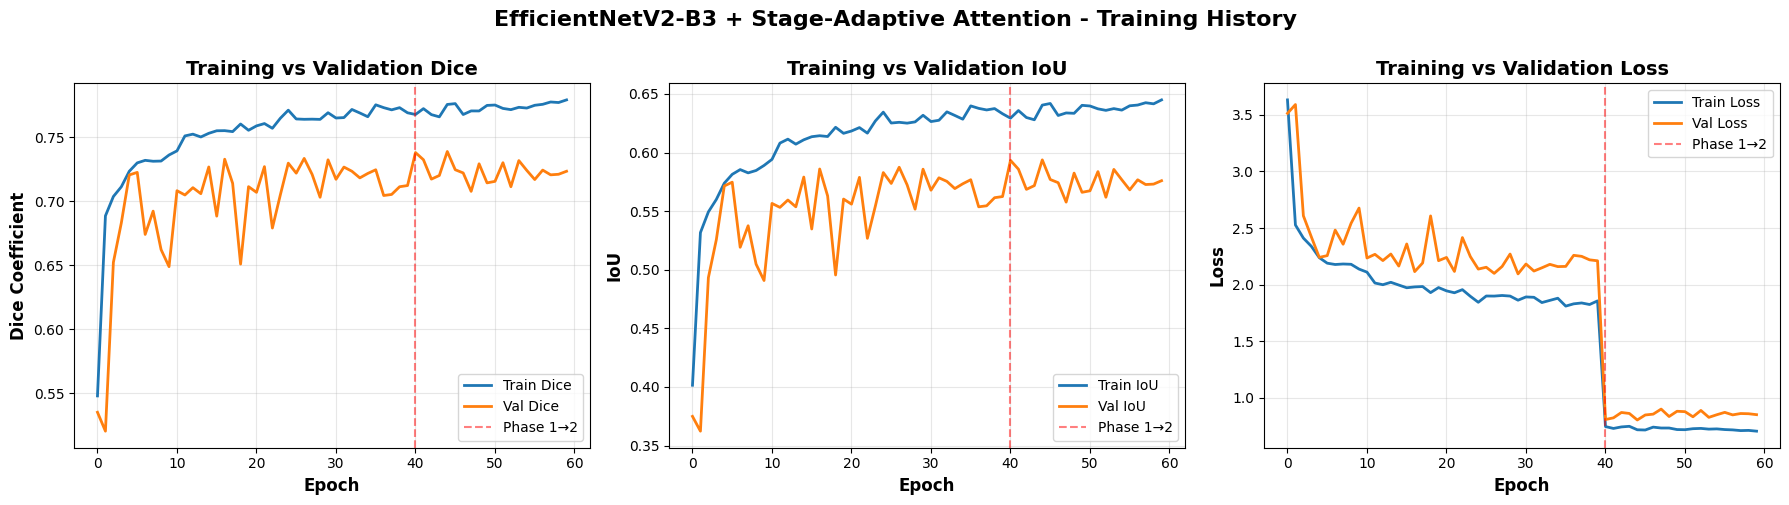

 Training history plots saved


In [17]:
# ============================================================================
# TRAINING HISTORY PLOTS
# ============================================================================

print("\n" + "="*80)
print(" CREATING TRAINING HISTORY PLOTS")
print("="*80)

# Combine histories
combined_history = {
    'loss': history_phase1.history['loss'] + history_phase2.history['loss'],
    'val_loss': history_phase1.history['val_loss'] + history_phase2.history['val_loss'],
    'dice_coefficient': history_phase1.history['dice_coefficient'] + history_phase2.history['dice_coefficient'],
    'val_dice_coefficient': history_phase1.history['val_dice_coefficient'] + history_phase2.history['val_dice_coefficient'],
    'iou_metric': history_phase1.history['iou_metric'] + history_phase2.history['iou_metric'],
    'val_iou_metric': history_phase1.history['val_iou_metric'] + history_phase2.history['val_iou_metric']
}

# Plot 1: Loss
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Dice curve
axes[0].plot(combined_history['dice_coefficient'], label='Train Dice', linewidth=2)
axes[0].plot(combined_history['val_dice_coefficient'], label='Val Dice', linewidth=2)
axes[0].axvline(len(history_phase1.history['loss']), color='red', linestyle='--', alpha=0.5, label='Phase 1→2')
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Dice Coefficient', fontsize=12, fontweight='bold')
axes[0].set_title('Training vs Validation Dice', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# IoU curve
axes[1].plot(combined_history['iou_metric'], label='Train IoU', linewidth=2)
axes[1].plot(combined_history['val_iou_metric'], label='Val IoU', linewidth=2)
axes[1].axvline(len(history_phase1.history['loss']), color='red', linestyle='--', alpha=0.5, label='Phase 1→2')
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('IoU', fontsize=12, fontweight='bold')
axes[1].set_title('Training vs Validation IoU', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Loss curve
axes[2].plot(combined_history['loss'], label='Train Loss', linewidth=2)
axes[2].plot(combined_history['val_loss'], label='Val Loss', linewidth=2)
axes[2].axvline(len(history_phase1.history['loss']), color='red', linestyle='--', alpha=0.5, label='Phase 1→2')
axes[2].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[2].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.suptitle('EfficientNetV2-B3 + Stage-Adaptive Attention - Training History', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('results_efficientnetv2b3_stageadaptive_attention_only/training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Training history plots saved")


 CREATING SAMPLE PREDICTION VISUALIZATIONS


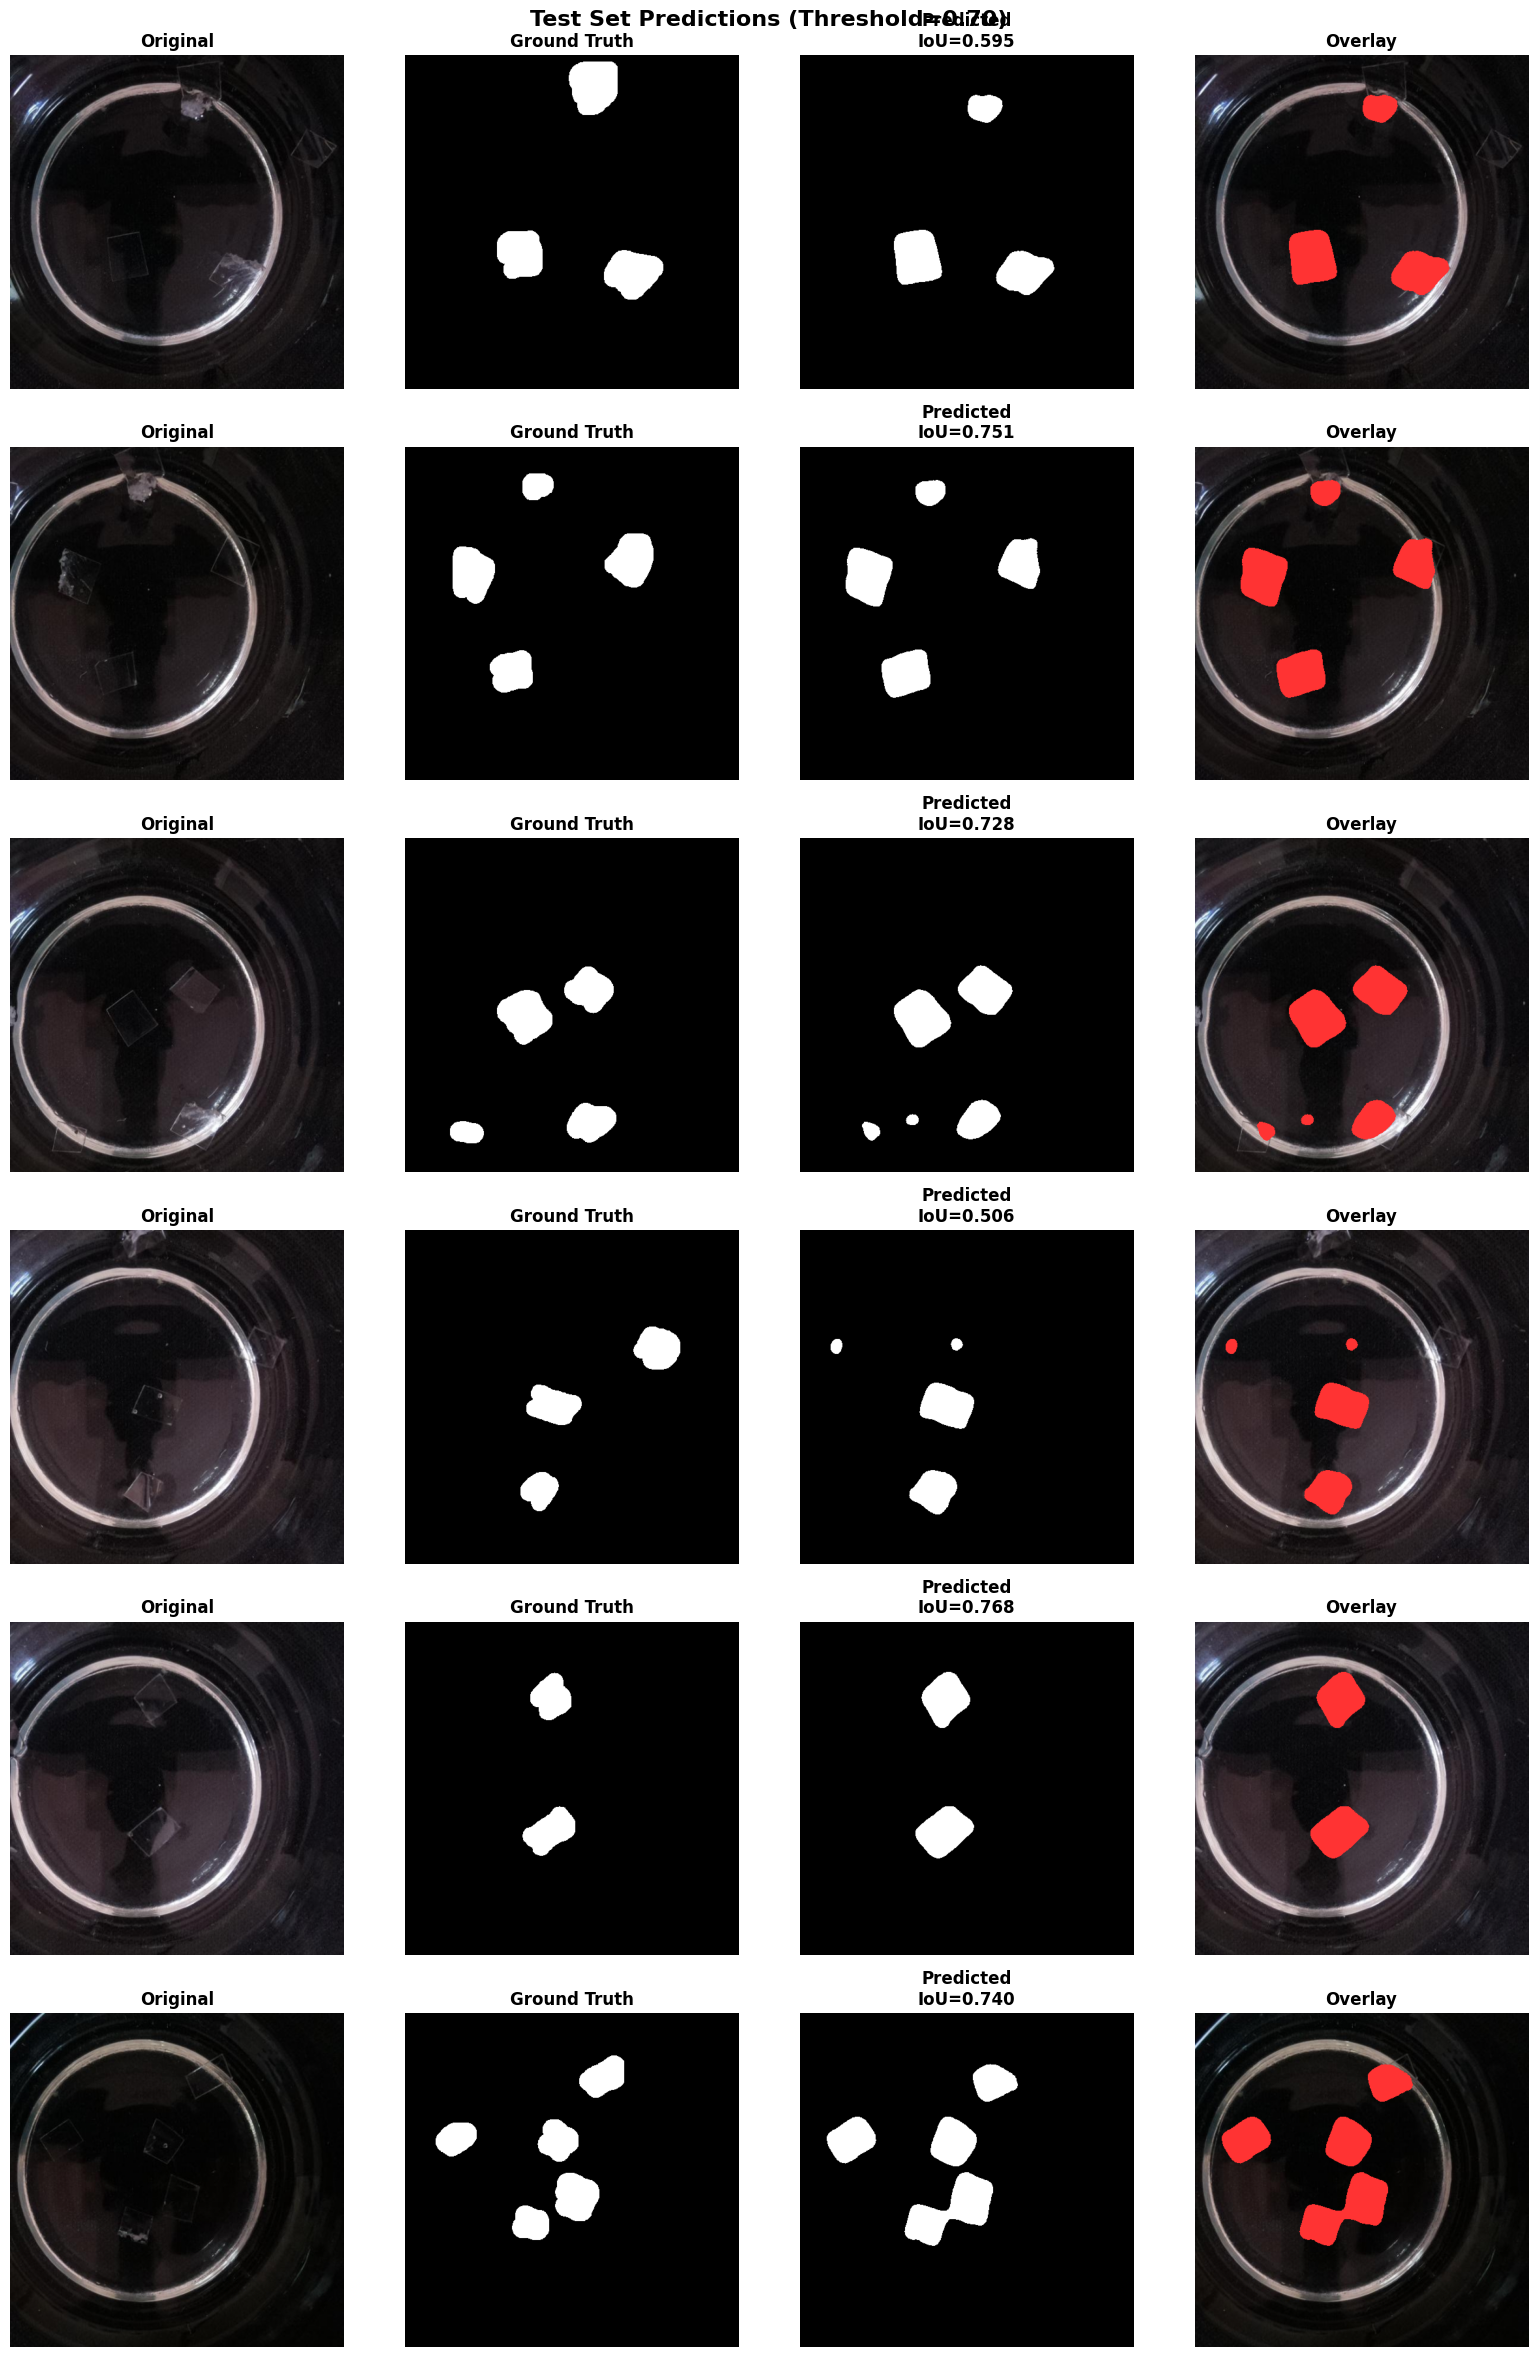

 Sample predictions visualization saved


In [18]:
# ============================================================================
# VISUALIZATION: SAMPLE PREDICTIONS
# ============================================================================

print("\n" + "="*80)
print(" CREATING SAMPLE PREDICTION VISUALIZATIONS")
print("="*80)

num_samples = min(6, len(X_test))
fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
if num_samples == 1:
    axes = axes.reshape(1, -1)

for idx in range(num_samples):
    img_display = np.clip(X_test[idx], 0, 1)
    gt_mask = y_test_binary[idx].squeeze()
    pred_mask = y_test_pred_binary[idx].squeeze()

    axes[idx, 0].imshow(img_display)
    axes[idx, 0].set_title('Original', fontweight='bold')
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(gt_mask, cmap='gray')
    axes[idx, 1].set_title('Ground Truth', fontweight='bold')
    axes[idx, 1].axis('off')

    iou = calculate_iou(gt_mask.flatten(), pred_mask.flatten())
    axes[idx, 2].imshow(pred_mask, cmap='gray')
    axes[idx, 2].set_title(f'Predicted\nIoU={iou:.3f}', fontweight='bold')
    axes[idx, 2].axis('off')

    overlay = img_display.copy()
    if len(overlay.shape) == 2:
        overlay = np.stack([overlay]*3, axis=-1)
    overlay[pred_mask > 0.5] = [1.0, 0.2, 0.2]
    axes[idx, 3].imshow(overlay)
    axes[idx, 3].set_title('Overlay', fontweight='bold')
    axes[idx, 3].axis('off')

plt.suptitle(f'Test Set Predictions (Threshold={SEG_THRESHOLD:.2f})',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('results_efficientnetv2b3_stageadaptive_attention_only/test_predictions.png',
            dpi=300, bbox_inches='tight')
plt.show()

print(" Sample predictions visualization saved")


 CREATING PERFORMANCE SUMMARY PLOTS


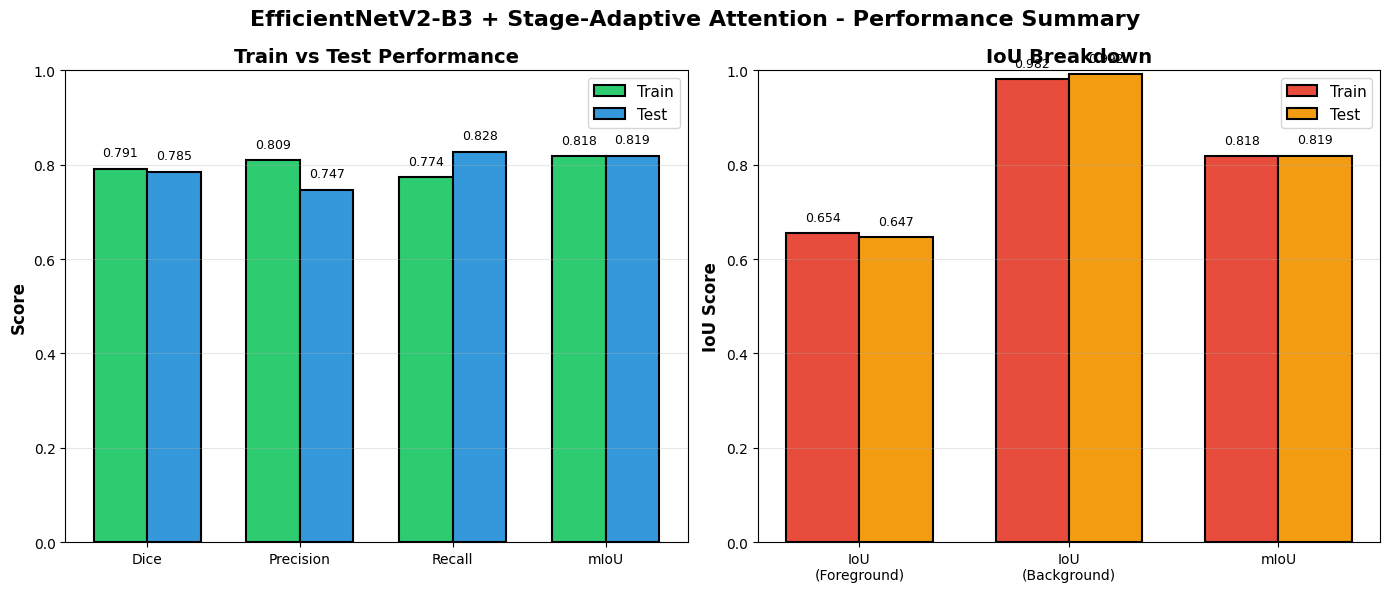

 Performance summary plot saved


In [19]:
# ============================================================================
# PERFORMANCE SUMMARY PLOTS
# ============================================================================

print("\n" + "="*80)
print(" CREATING PERFORMANCE SUMMARY PLOTS")
print("="*80)

fig = plt.figure(figsize=(14, 6))

# Metrics bar chart
ax1 = plt.subplot(1, 2, 1)
metrics_names = ['Dice', 'Precision', 'Recall', 'mIoU']
train_values = [train_metrics['dice'], train_metrics['precision'],
                train_metrics['recall'], train_metrics['miou']]
test_values = [test_metrics['dice'], test_metrics['precision'],
               test_metrics['recall'], test_metrics['miou']]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax1.bar(x - width/2, train_values, width, label='Train', color='#2ecc71', edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x + width/2, test_values, width, label='Test', color='#3498db', edgecolor='black', linewidth=1.5)

ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Train vs Test Performance', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_names)
ax1.set_ylim(0, 1.0)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# IoU breakdown
ax2 = plt.subplot(1, 2, 2)
iou_names = ['IoU\n(Foreground)', 'IoU\n(Background)', 'mIoU']
train_iou = [train_metrics['iou_foreground'], train_metrics['iou_background'], train_metrics['miou']]
test_iou = [test_metrics['iou_foreground'], test_metrics['iou_background'], test_metrics['miou']]

x_iou = np.arange(len(iou_names))
bars3 = ax2.bar(x_iou - width/2, train_iou, width, label='Train', color='#e74c3c', edgecolor='black', linewidth=1.5)
bars4 = ax2.bar(x_iou + width/2, test_iou, width, label='Test', color='#f39c12', edgecolor='black', linewidth=1.5)

ax2.set_ylabel('IoU Score', fontsize=12, fontweight='bold')
ax2.set_title('IoU Breakdown', fontsize=14, fontweight='bold')
ax2.set_xticks(x_iou)
ax2.set_xticklabels(iou_names)
ax2.set_ylim(0, 1.0)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('EfficientNetV2-B3 + Stage-Adaptive Attention - Performance Summary', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('results_efficientnetv2b3_stageadaptive_attention_only/performance_summary.png',
            dpi=300, bbox_inches='tight')
plt.show()

print(" Performance summary plot saved")

In [20]:
# ============================================================================
# FINAL RESULTS REPORT
# ============================================================================

print("\n" + "="*80)
print(" FINAL RESULTS REPORT - ABLATION 3: EfficientNetV2-B3 + STAGE-ADAPTIVE ATTENTION")
print("="*80)

report = f"""
{'='*80}
ABLATION 3: EfficientNetV2-B3 + STAGE-ADAPTIVE ATTENTION (NO MRFM)
{'='*80}

CONFIGURATION:
  Input size: {IMG_HEIGHT} × {IMG_WIDTH} × 3
  Batch size: {BATCH_SIZE}
  Train samples: {len(X_train)}
  Validation samples: {len(X_val)}
  Test samples: {len(X_test)}
  Random seed: 42

MODEL ARCHITECTURE:
  Encoder: EfficientNetV2B3 (ImageNet pretrained)
  Decoder: U-Net with skip connections + Stage-Adaptive Attention at every stage
  Attention: Edge Attention (early) / Coordinate Attention (middle) / Channel-Spatial Attention (deep)
  MRFM modules present: {mrfm_layer_count}
  Total parameters: {model_total_params:,}
  Trainable parameters: {model_trainable_params:,}

TRAINING STRATEGY:
  Phase 1: Frozen backbone, train decoder (40 epochs)
  Phase 2: Fine-tune full model (up to {EPOCHS} epochs)
  Phase 1 best Dice: {best_dice_phase1:.4f}
  Phase 2 best Dice: {best_dice_phase2:.4f}
  Phase 2 best IoU: {best_iou_phase2:.4f}
  Total epochs completed: {epochs_completed}
  Early stopping patience: {PATIENCE}

LOSS FUNCTIONS:
  Phase 1: Aggressive Imbalance Loss (5×Dice + 3×Tversky + 1×Focal)
  Phase 2: Focal Dice Loss (3×Dice + 1×Focal)
  Optimizer (Phase 1): Adam (lr=1e-3)
  Optimizer (Phase 2): AdamW (lr=5e-5, wd=1e-5)

AUGMENTATION (Training only):
  - Rotation (±15°)
  - Zoom (0.9-1.1×)
  - Horizontal flip (50%)
  - Vertical flip (50%)
  - Brightness adjustment (±0.05)
  - Contrast adjustment (0.95-1.05×)
  - Gamma adjustment (0.95-1.05)
  - Gaussian noise (σ=0.005)

THRESHOLD TUNING:
  Validation set threshold search: 0.1 - 0.7 (13 steps)
  Optimal threshold: {SEG_THRESHOLD:.2f}
  Validation Dice at optimal: {best_dice:.4f}

{'='*80}
TRAINING SET METRICS (Threshold={SEG_THRESHOLD:.2f})
{'='*80}
  Dice Coefficient:     {train_metrics['dice']:.4f}
  Precision:            {train_metrics['precision']:.4f}
  Recall:               {train_metrics['recall']:.4f}
  Foreground IoU:       {train_metrics['iou_foreground']:.4f}
  Background IoU:       {train_metrics['iou_background']:.4f}
  mIoU:                 {train_metrics['miou']:.4f}

{'='*80}
TEST SET METRICS (Threshold={SEG_THRESHOLD:.2f})
{'='*80}
  Dice Coefficient:     {test_metrics['dice']:.4f}
  Precision:            {test_metrics['precision']:.4f}
  Recall:               {test_metrics['recall']:.4f}
  Foreground IoU:       {test_metrics['iou_foreground']:.4f}
  Background IoU:       {test_metrics['iou_background']:.4f}
  mIoU:                 {test_metrics['miou']:.4f}

{'='*80}
RESULTS SUMMARY TABLE
{'='*80}
"""

print(report)
print(results_df.to_string(index=False))

# Save report
with open('results_efficientnetv2b3_stageadaptive_attention_only/ablation3_report.txt', 'w') as f:
    f.write(report)
    f.write("\n\n")
    f.write(results_df.to_string(index=False))
    f.write("\n\n")
    f.write(f"{'='*80}\n")
    f.write("INTERPRETATION\n")
    f.write(f"{'='*80}\n")
    f.write("This ablation isolates the contribution of Stage-Adaptive Attention.\n")
    f.write("It establishes the performance WITH Stage-Adaptive Attention and WITHOUT MRFM.\n")
    f.write("Ablation 3 minus Ablation 1 represents the effect of Stage-Adaptive Attention alone.\n")

print(f"\n Report saved to 'results_efficientnetv2b3_stageadaptive_attention_only/ablation3_report.txt'")
print("="*80)


 FINAL RESULTS REPORT - ABLATION 3: EfficientNetV2-B3 + STAGE-ADAPTIVE ATTENTION

ABLATION 3: EfficientNetV2-B3 + STAGE-ADAPTIVE ATTENTION (NO MRFM)

CONFIGURATION:
  Input size: 512 × 512 × 3
  Batch size: 4
  Train samples: 556
  Validation samples: 100
  Test samples: 100
  Random seed: 42

MODEL ARCHITECTURE:
  Encoder: EfficientNetV2B3 (ImageNet pretrained)
  Decoder: U-Net with skip connections + Stage-Adaptive Attention at every stage
  Attention: Edge Attention (early) / Coordinate Attention (middle) / Channel-Spatial Attention (deep)
  MRFM modules present: 0
  Total parameters: 17,355,440
  Trainable parameters: 8,884,020

TRAINING STRATEGY:
  Phase 1: Frozen backbone, train decoder (40 epochs)
  Phase 2: Fine-tune full model (up to 100 epochs)
  Phase 1 best Dice: 0.7334
  Phase 2 best Dice: 0.7388
  Phase 2 best IoU: 0.5937
  Total epochs completed: 60
  Early stopping patience: 15

LOSS FUNCTIONS:
  Phase 1: Aggressive Imbalance Loss (5×Dice + 3×Tversky + 1×Focal)
  Phase

In [21]:
# ============================================================================
# SAVE COMPLETE TRAINING HISTORY
# ============================================================================

print("\n" + "="*80)
print(" SAVING COMPLETE TRAINING HISTORY")
print("="*80)

history_df = pd.DataFrame(combined_history)
history_df.to_csv('results_efficientnetv2b3_stageadaptive_attention_only/training_history.csv', index=False)

print(" Training history saved to CSV")
print(f"\n Training history shape: {history_df.shape}")
print(f" Columns: {list(history_df.columns)}")
print(f"\n First few rows:")
print(history_df.head())
print(f"\n Last few rows:")
print(history_df.tail())


 SAVING COMPLETE TRAINING HISTORY
 Training history saved to CSV

 Training history shape: (60, 6)
 Columns: ['loss', 'val_loss', 'dice_coefficient', 'val_dice_coefficient', 'iou_metric', 'val_iou_metric']

 First few rows:
       loss  val_loss  dice_coefficient  val_dice_coefficient  iou_metric  \
0  3.632260  3.513274          0.548091              0.535329    0.401467   
1  2.526800  3.591223          0.688580              0.520593    0.531696   
2  2.411024  2.608060          0.703659              0.652299    0.549334   
3  2.338461  2.421975          0.711280              0.683101    0.559981   
4  2.238033  2.240436          0.723368              0.720491    0.573827   

   val_iou_metric  
0        0.374930  
1        0.362305  
2        0.493278  
3        0.525662  
4        0.571480  

 Last few rows:
        loss  val_loss  dice_coefficient  val_dice_coefficient  iou_metric  \
55  0.718981  0.870929          0.774852              0.716920    0.639866   
56  0.716065  0.848

In [22]:
# ============================================================================
# SUMMARY PRINT
# ============================================================================

print("\n" + "#"*80)
print("#" + " "*78 + "#")
print("#" + " "*24 + "ABLATION 3 COMPLETE" + " "*34 + "#")
print("#" + " "*78 + "#")
print("#"*80)

print(f"""
MODEL:        EfficientNetV2-B3 + Stage-Adaptive Attention (NO MRFM)
PARAMETERS:   {model_total_params:,} total, {model_trainable_params:,} trainable
EPOCHS:       {epochs_completed}
BEST VAL DICE: {best_dice:.4f}
BEST VAL IOU:  {best_iou_phase2:.4f}
VALIDATION THRESHOLD (frozen): {SEG_THRESHOLD:.2f}
MRFM MODULES PRESENT: {mrfm_layer_count}

TEST PERFORMANCE:
  Dice:             {test_metrics['dice']:.4f}
  Precision:        {test_metrics['precision']:.4f}
  Recall:           {test_metrics['recall']:.4f}
  mIoU:             {test_metrics['miou']:.4f}
  Foreground IoU:   {test_metrics['iou_foreground']:.4f}
  Background IoU:   {test_metrics['iou_background']:.4f}

OUTPUTS:
  results_efficientnetv2b3_stageadaptive_attention_only/results.csv
  ablation_3_efficientnetv2b3_attention_results.csv
  results_efficientnetv2b3_stageadaptive_attention_only/training_history.csv
  results_efficientnetv2b3_stageadaptive_attention_only/training_history.png
  results_efficientnetv2b3_stageadaptive_attention_only/test_predictions.png
  results_efficientnetv2b3_stageadaptive_attention_only/performance_summary.png
  results_efficientnetv2b3_stageadaptive_attention_only/ablation3_report.txt

READY FOR COMPARISON:
  -> Ablation 1 (Baseline) vs Ablation 3 (Baseline + Stage-Adaptive Attention)
     isolates the contribution of Stage-Adaptive Attention alone.
""")

print("#"*80)

print("\nFINAL TRAIN AND TEST METRICS TABLE")
print(results_df.to_string(index=False))



################################################################################
#                                                                              #
#                        ABLATION 3 COMPLETE                                  #
#                                                                              #
################################################################################

MODEL:        EfficientNetV2-B3 + Stage-Adaptive Attention (NO MRFM)
PARAMETERS:   17,355,440 total, 8,884,020 trainable
EPOCHS:       60
BEST VAL DICE: 0.8202
BEST VAL IOU:  0.5937
VALIDATION THRESHOLD (frozen): 0.70
MRFM MODULES PRESENT: 0

TEST PERFORMANCE:
  Dice:             0.7854
  Precision:        0.7473
  Recall:           0.8276
  mIoU:             0.8192
  Foreground IoU:   0.6466
  Background IoU:   0.9918

OUTPUTS:
  results_efficientnetv2b3_stageadaptive_attention_only/results.csv
  ablation_3_efficientnetv2b3_attention_results.csv
  results_efficientnetv2b3_stageadaptive_